In [10]:
import pandas as pd
import numpy as np

df = pd.read_parquet("data/processed/BTCUSDT_5m_regularized.parquet")

df["open_time"] = pd.to_datetime(df["open_time"])
df = df.sort_values("open_time").reset_index(drop=True)
df.head()

,open_time,open,high,low,close,volume
0,2019-01-01 00:00:00,3701.23,3703.72,3695.00,3696.32,85.572181
1,2019-01-01 00:05:00,3696.30,3697.24,3689.88,3692.34,62.296581
2,2019-01-01 00:10:00,3692.34,3698.93,3692.34,3697.31,43.105333
3,2019-01-01 00:15:00,3697.91,3698.75,3693.00,3693.00,48.551084
4,2019-01-01 00:20:00,3693.44,3695.98,3690.92,3692.18,47.706443


In [11]:
df["log_close"] = np.log(df["close"])
df["returns"] = df["log_close"].diff()
df = df.dropna().reset_index(drop=True)

In [12]:
from scipy.stats import skew, kurtosis

df["returns"].describe()
skew(df["returns"]), kurtosis(df["returns"])

(np.float64(-0.1914766446025681), np.float64(166.65566386464698))

In [13]:
df["rolling_vol"] = df["returns"].rolling(96).std()

In [14]:
df["rolling_vol"].describe()

count    631200.000000
mean          0.001741
std           0.001280
min           0.000000
25%           0.000998
50%           0.001452
75%           0.002092
max           0.029338
Name: rolling_vol, dtype: float64

Matplotlib is building the font cache; this may take a moment.


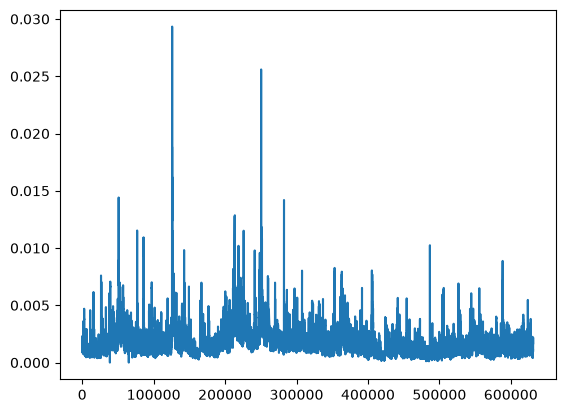

In [15]:
import matplotlib.pyplot as plt

plt.plot(df["rolling_vol"])
plt.show()

In [17]:
for col in df.columns:
    print(col)

open_time
open
high
low
close
volume
log_close
returns
rolling_vol


In [18]:
df['rolling_vol'].describe()

count    631200.000000
mean          0.001741
std           0.001280
min           0.000000
25%           0.000998
50%           0.001452
75%           0.002092
max           0.029338
Name: rolling_vol, dtype: float64

In [19]:
df['rolling_vol'].head(20)


0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
Name: rolling_vol, dtype: float64

In [20]:
window = 48

df['rv'] = (df['returns'] ** 2).rolling(window=window).sum()

df = df.dropna(subset=['rv'])

df['rv_smooth'] = df['rv'].ewm(span=10, adjust=False).mean()

In [21]:
df[['returns', 'rv', 'rv_smooth']].head(10)

,returns,rv,rv_smooth
47,0.000766,0.000041,0.000041
48,0.002713,0.000047,0.000042
49,0.000318,0.000045,0.000043
50,-0.000281,0.000044,0.000043
51,-0.002696,0.000051,0.000044
52,0.000097,0.000051,0.000046
53,0.000446,0.000047,0.000046
54,-0.000549,0.000048,0.000046
55,-0.000447,0.000048,0.000046
56,0.000422,0.000045,0.000046


In [22]:
q1 = df['rv_smooth'].quantile(1/3)
q2 = df['rv_smooth'].quantile(2/3)

df['regime'] = np.where(df['rv_smooth'] <= q1, 0,
                  np.where(df['rv_smooth'] <= q2, 1, 2))

In [23]:
df['regime'].value_counts(normalize=True)

regime
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64

In [24]:
import pandas as pd

transition = pd.crosstab(df['regime'], df['regime'].shift(-1), normalize=0)
transition

regime,0.0,1.0,2.0
regime,,,
0,0.990257,0.009681,0.000062
1,0.009738,0.980510,0.009752
2,0.000000,0.009814,0.990186


In [25]:
transition.values.diagonal()

array([0.99025739, 0.98050994, 0.99018611])

In [26]:
df_shuffled = df.copy()
df_shuffled['regime'] = np.random.permutation(df_shuffled['regime'].values)

transition_shuffled = pd.crosstab(
    df_shuffled['regime'],
    df_shuffled['regime'].shift(-1),
    normalize=0
)

transition_shuffled

regime,0.0,1.0,2.0
regime,,,
0,0.333192,0.333097,0.333710
1,0.333260,0.333422,0.333317
2,0.333549,0.333477,0.332974


In [27]:
regime_stats = df.groupby('regime')['returns'].agg([
    'mean',
    'std',
    'count'
])

print(regime_stats)

            mean       std   count
regime                            
0       0.000004  0.000916  210416
1       0.000003  0.001567  210416
2       0.000008  0.003269  210416


In [28]:
df.groupby('regime')['returns'].quantile(
    [0.01,0.05,0.25,0.5,0.75,0.95,0.99]
)

regime      
0       0.01   -0.002472
        0.05   -0.001350
        0.25   -0.000445
        0.50    0.000000
        0.75    0.000452
        0.95    0.001367
        0.99    0.002504
1       0.01   -0.004192
        0.05   -0.002282
        0.25   -0.000805
        0.50    0.000000
        0.75    0.000825
        0.95    0.002286
        0.99    0.004136
2       0.01   -0.008648
        0.05   -0.004288
        0.25   -0.001363
        0.50    0.000002
        0.75    0.001393
        0.95    0.004314
        0.99    0.008556
Name: returns, dtype: float64

In [29]:
future_return = df['returns'].shift(-1)

df.groupby('regime').apply(
    lambda x: future_return.loc[x.index].mean()
)

regime
0    0.000001
1    0.000004
2    0.000010
dtype: float64

In [30]:
df['future_return'] = df['returns'].shift(-1)

df.groupby('regime')['future_return'].agg([
    'mean',
    'std',
    'count'
])

,mean,std,count
regime,,,
0,0.000001,0.001036,210416
1,0.000004,0.001647,210415
2,0.000010,0.003192,210416
